##import libraries , load, merge  & check data

In [ ]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
fact = pd.read_csv("/content/fact_bitcoin_market.csv",low_memory=False)
dim_timeframe = pd.read_csv("/content/dim_timeframe.csv",low_memory=False)
dim_date = pd.read_csv("/content/dim_date.csv",low_memory=False)

In [ ]:
dim_date["Open time"] = pd.to_datetime(dim_date["Open time"])

In [ ]:
fact.info()
dim_date.info()
dim_timeframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391385 entries, 0 to 391384
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date_key                391385 non-null  int64  
 1   timeframe_key           391385 non-null  int64  
 2   Open                    391385 non-null  float64
 3   High                    391385 non-null  float64
 4   Low                     391385 non-null  float64
 5   Close                   391385 non-null  float64
 6   Volume                  391385 non-null  float64
 7   capital_flow            391385 non-null  float64
 8   trade_activity          391385 non-null  int64  
 9   price_change            391385 non-null  float64
 10  return_pct              391385 non-null  float64
 11  volatility              391385 non-null  float64
 12  buy_volume              391385 non-null  float64
 13  sell_volume             391385 non-null  float64
 14  buy_ratio           

In [ ]:
print(fact.shape)
print(dim_date.shape)
print(dim_timeframe.shape)

(391385, 32)
(391385, 7)
(4, 2)


In [ ]:
# Merge
rows_before = len(fact)


dim_date = dim_date.drop(columns=["timeframe"])

# Merge Date Dimension
df = fact.merge(dim_date, on="date_key", how="left")
assert len(df) == rows_before, "dim_date merge changed row count - duplication bug!"

# Merge Timeframe Dimension
df = df.merge(dim_timeframe, on="timeframe_key", how="left")
assert len(df) == rows_before, "dim_timeframe merge changed row count - duplication bug!"

print("Row count stable after merges:", len(df), "(expected:", rows_before, ")")
print("Shape:", df.shape)

df.info()
df.describe()

Row count stable after merges: 391385 (expected: 391385 )
Shape: (391385, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391385 entries, 0 to 391384
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   date_key                391385 non-null  int64              
 1   timeframe_key           391385 non-null  int64              
 2   Open                    391385 non-null  float64            
 3   High                    391385 non-null  float64            
 4   Low                     391385 non-null  float64            
 5   Close                   391385 non-null  float64            
 6   Volume                  391385 non-null  float64            
 7   capital_flow            391385 non-null  float64            
 8   trade_activity          391385 non-null  int64              
 9   price_change            391385 non-null  float64            
 10  return_pct    

,date_key,timeframe_key,Open,High,Low,Close,Volume,capital_flow,trade_activity,price_change,...,overheating,whale_activity,breakout_up,breakout_down,support,resistance,year,quarter,month,day
count,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,3.913850e+05,3.913850e+05,391385.000000,...,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.000000,391385.00000,391385.000000
mean,195693.000000,1.306862,39333.158370,39440.500293,39221.160604,39333.803455,1967.862692,5.651153e+07,6.305021e+04,0.645085,...,0.014822,0.009584,0.039570,0.035045,112.642851,106.696838,2021.748112,2.453175,6.35219,15.691511
std,112983.261891,0.595019,32557.861859,32624.286368,32489.537836,32558.025841,9628.280507,2.517477e+08,2.731712e+05,237.837448,...,0.120839,0.097427,0.194946,0.183893,224.266704,209.250489,2.447237,1.117984,3.45284,8.798631
min,1.000000,1.000000,3166.110000,3174.780000,3156.260000,3167.070000,0.000000,0.000000e+00,0.000000e+00,-8049.380000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018.000000,1.000000,1.00000,1.000000
25%,97847.000000,1.000000,9694.630000,9726.740000,9660.740000,9694.650000,220.138490,4.994906e+06,6.178000e+03,-39.040000,...,0.000000,0.000000,0.000000,0.000000,14.310000,12.970000,2020.000000,1.000000,3.00000,8.000000
50%,195693.000000,1.000000,29325.900000,29379.830000,29276.880000,29326.690000,469.253358,1.402873e+07,1.555700e+04,0.310000,...,0.000000,0.000000,0.000000,0.000000,43.890000,40.860000,2022.000000,2.000000,6.00000,16.000000
75%,293539.000000,1.000000,62212.790000,62405.300000,62037.800000,62213.840000,1261.560966,3.799360e+07,4.372500e+04,40.800000,...,0.000000,0.000000,0.000000,0.000000,124.860000,118.810000,2024.000000,3.000000,9.00000,23.000000
max,391385.000000,4.000000,126011.180000,126199.630000,125648.010000,126011.180000,760705.362783,1.746531e+10,1.522359e+07,8277.980000,...,1.000000,1.000000,1.000000,1.000000,11451.860000,8368.690000,2026.000000,4.000000,12.00000,31.000000


In [ ]:
df = df.sort_values("Open time")
df = df.reset_index(drop=True)

##EDA

Explore price change and volatility across different timeframes to identify variability and detect potential outliers.

**Insight (Full dataset )**

---


Price change and volatility span a wide range, reaching approximately ±8,000 for price change and up to 15,000 for volatility. Given the dataset covers the Bitcoin market from 2018 onward, these extreme values likely represent major market events such as strong rallies, crashes, or periods of exceptionally high volatility rather than data errors.

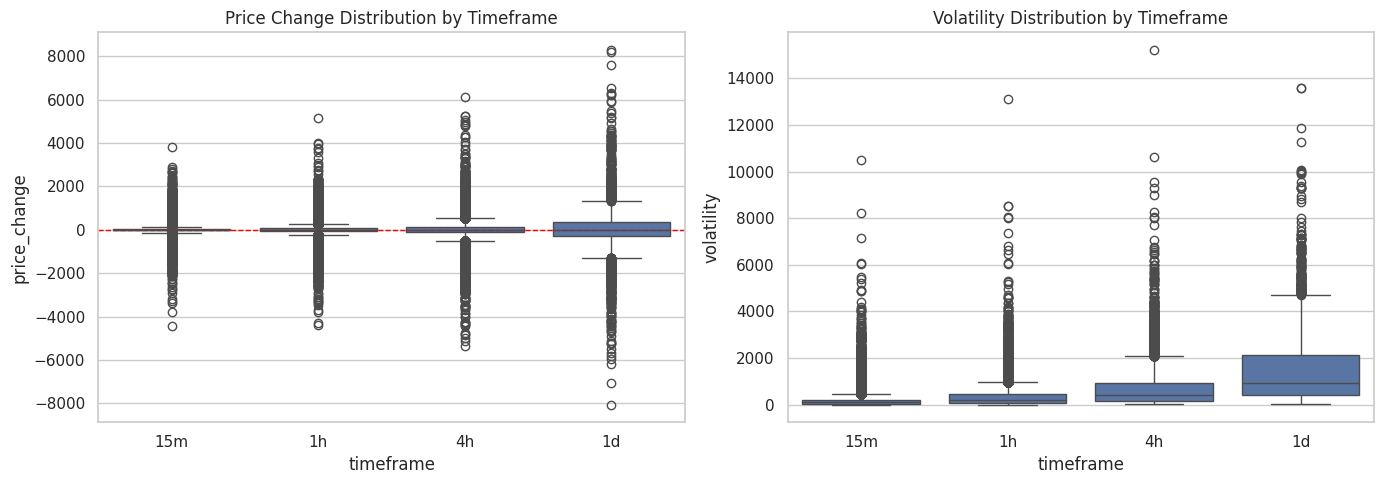

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="timeframe", y="price_change", ax=axes[0])
axes[0].set_title("Price Change Distribution by Timeframe")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)

sns.boxplot(data=df, x="timeframe", y="volatility", ax=axes[1])
axes[1].set_title("Volatility Distribution by Timeframe")

plt.tight_layout()
plt.show()

 Explore trend length distribution across different timeframes to understand how long market trends typically persist.


**Insight (Full dataset )**

---


Most market trends remain short-lived, with the majority lasting only 1–2 consecutive candles(row). Trends extending beyond 5–6 candles are relatively rare, indicating that prolonged directional movements are uncommon even across the full historical dataset.

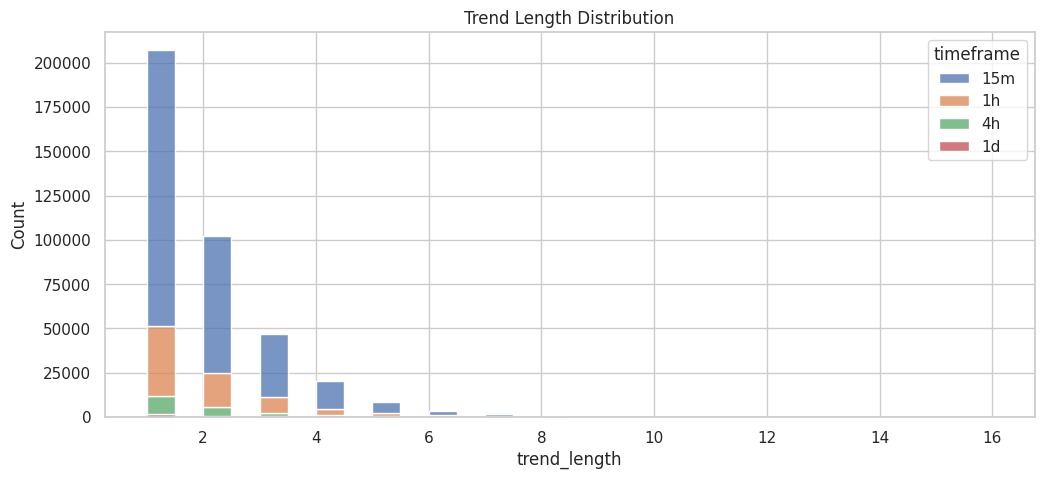

In [ ]:


plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="trend_length",
    hue="timeframe",
    bins=30,
    multiple="stack"
)

plt.title("Trend Length Distribution")

plt.show()

 Explore buy ratio distribution across different timeframes to evaluate buyer dominance and buying pressure.

 **Insight (Full dataset )**

---

 The buy ratio remains strongly centered around 50% across the entire dataset, indicating that the market is generally balanced. Buyer or seller dominance occurs only during specific periods rather than representing the market's normal state.

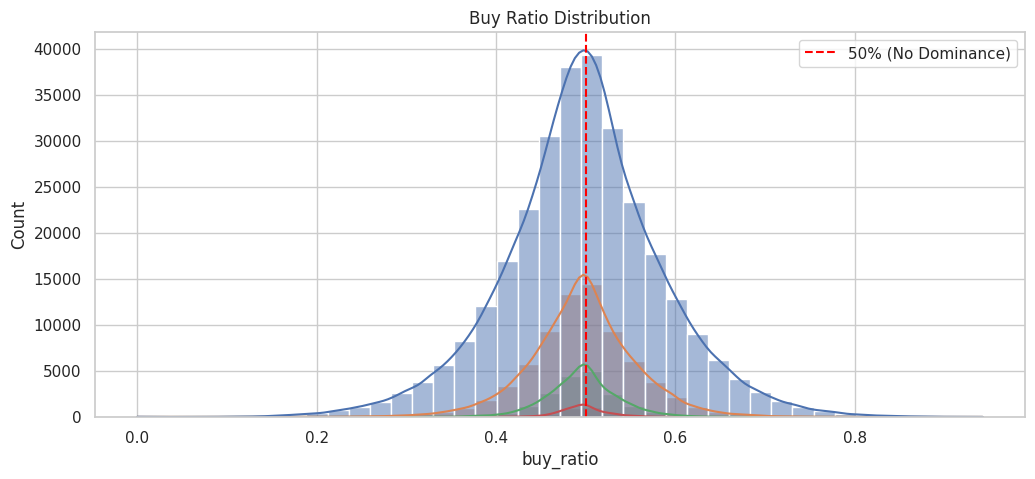

In [ ]:

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="buy_ratio",
    hue="timeframe",
    bins=40,
    kde=True
)

plt.axvline(0.5, color="red", linestyle="--", label="50% (No Dominance)")

plt.title("Buy Ratio Distribution")

plt.legend()

plt.show()

 Explore trade activity across different timeframesto compare market participation and trading intensity.

**Insight (Full dataset )**

---

An extreme outlier of approximately 1.5 million trades appears in the daily timeframe, suggesting an exceptional trading day with unusually high market participation. This event is worth investigating further by identifying its exact date.

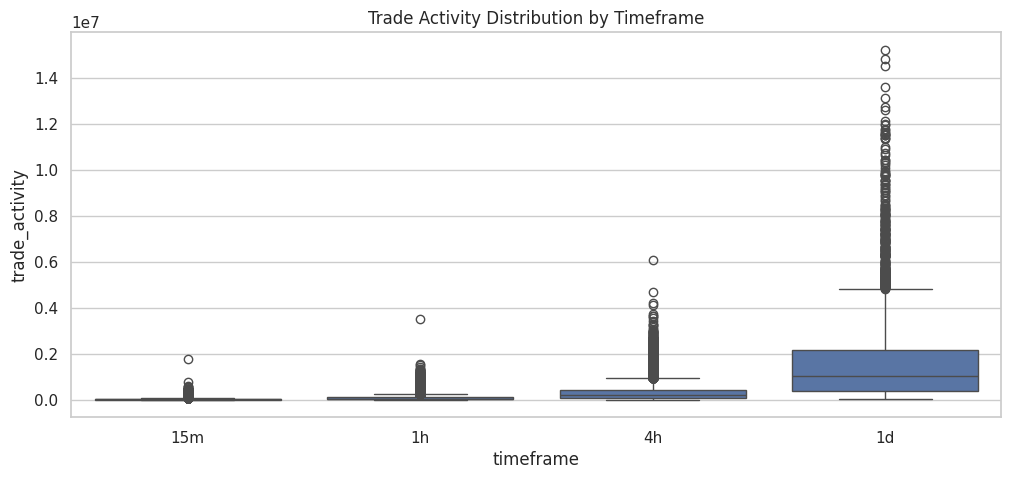

In [ ]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="timeframe",
    y="trade_activity"
)

plt.title("Trade Activity Distribution by Timeframe")

plt.show()

 Explore average volatility over time to observe long-term changes in market volatility.

**Insight (Full dataset )**

---
Average volatility exhibits clear cyclical behavior rather than remaining constant over time. Major volatility peaks are observed around 2021 and 2025, while the period between 2018 and 2020 appears relatively stable. This indicates that the Bitcoin market alternates between periods of low and high volatility over its market cycles.

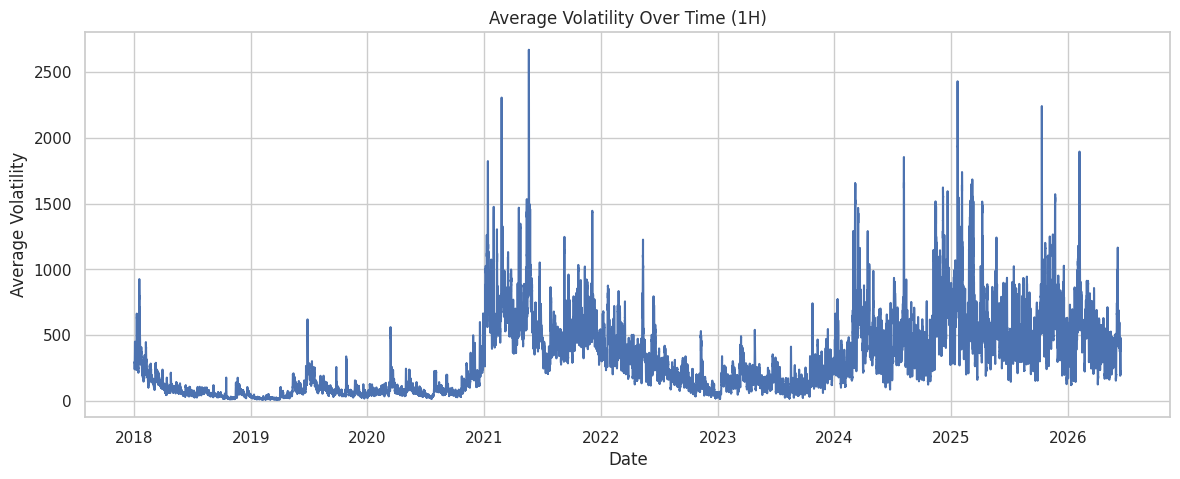

In [ ]:
sample_tf = (
    df[df["timeframe"] == "1h"]
    .sort_values("Open time")
)

plt.figure(figsize=(14, 5))

plt.plot(
    sample_tf["Open time"],
    sample_tf["avg_volatility_20"]
)

plt.title("Average Volatility Over Time (1H)")
plt.xlabel("Date")
plt.ylabel("Average Volatility")

plt.show()

 Explore correlations between key market variables to understand relationships between price movement, volume, and volatility.

**Insight (Full dataset )**


---


The correlation analysis reveals that volume-related variables (Volume, buy_volume, and sell_volume) are perfectly correlated (1.00), which is expected since they are mathematically dependent components of total volume rather than independent signals.
Interestingly, price_change shows almost no meaningful correlation with other variables, indicating that short-term price movements are largely independent of trading volume and activity intensity in this dataset.
A strong positive relationship is observed between trade_activity, capital_flow, and Volume (0.79–0.90), suggesting that these variables collectively represent overall market activity from different perspectives.
Volatility shows a moderate correlation with trade_activity and capital_flow (0.55–0.58), indicating that higher activity levels are generally associated with increased market fluctuations, but the relationship is not strongly linear.



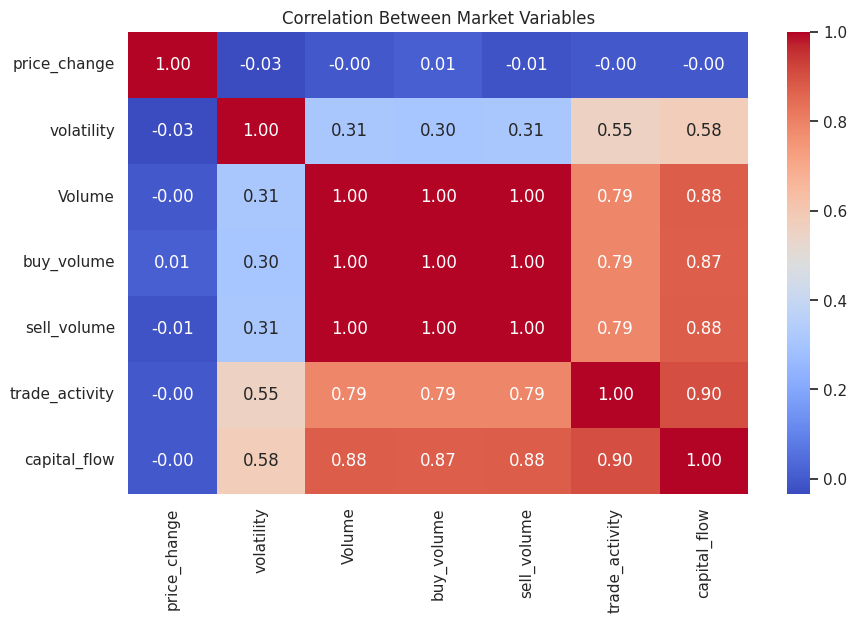

In [ ]:
corr_cols = [
    "price_change",
    "volatility",
    "Volume",
    "buy_volume",
    "sell_volume",
    "trade_activity",
    "capital_flow"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Market Variables")

plt.show()

##FILTER

In [ ]:
# ==========================================
# EDA Filters
# Change these values to analyze different data
# ==========================================

# ========= Filters =========

selected_year = None          # Example: 2024
selected_quarter = None       # Example: 1, 2, 3, 4
selected_month = None         # Example: 1 , 2, 5
selected_day = None           # Example: 15

# Default timeframe (choose one only)
selected_timeframe = "1d"     # Change to "4h" , "1h" or "15m"if needed


# ========= Apply Filters =========

df_filtered = df.copy()

if selected_timeframe is not None:
    df_filtered = df_filtered[df_filtered["timeframe"] == selected_timeframe]

if selected_year is not None:
    df_filtered = df_filtered[df_filtered["year"] == selected_year]

if selected_quarter is not None:
    df_filtered = df_filtered[df_filtered["quarter"] == selected_quarter]

if selected_month is not None:
    df_filtered = df_filtered[df_filtered["month"] == selected_month]

if selected_day is not None:
    df_filtered = df_filtered[df_filtered["day"] == selected_day]


# ========= Current Filters =========

print("========== EDA FILTERS ==========")
print(f"Timeframe : {selected_timeframe}")
print(f"Year      : {selected_year}")
print(f"Quarter   : {selected_quarter}")
print(f"Month     : {selected_month}")
print(f"Day       : {selected_day}")
print(f"Rows after filtering: {len(df_filtered):,}")

========== EDA FILTERS ==========
Timeframe : 1d
Year      : None
Quarter   : None
Month     : None
Day       : None
Rows after filtering: 3,060


##**Dashboards**




#"Note: The following charts represent the 1d timeframe. To view a different timeframe,please adjust the filter."

#Markert Overview dashboard

In [ ]:
#KPI CARDS

print(f"""
Total Return %      : {df_filtered["return_pct"].sum():,.2f}
Average Volume      : {df_filtered["Volume"].mean():,.2f}
Average Capital Flow: {df_filtered["capital_flow"].mean():,.2f}
Average Volatility  : {df_filtered["volatility"].mean():,.2f}
""")


Total Return %      : 3.96
Average Volume      : 61,643.03
Average Capital Flow: 1,701,419,369.88
Average Volatility  : 1,496.78



**What is the Overall price movment?**

This chart shows the overall price movement within each time interval by measuring the difference between Open and Close prices.
It helps identify whether the market is in a bullish or bearish state over time and highlights short-term directional trends.

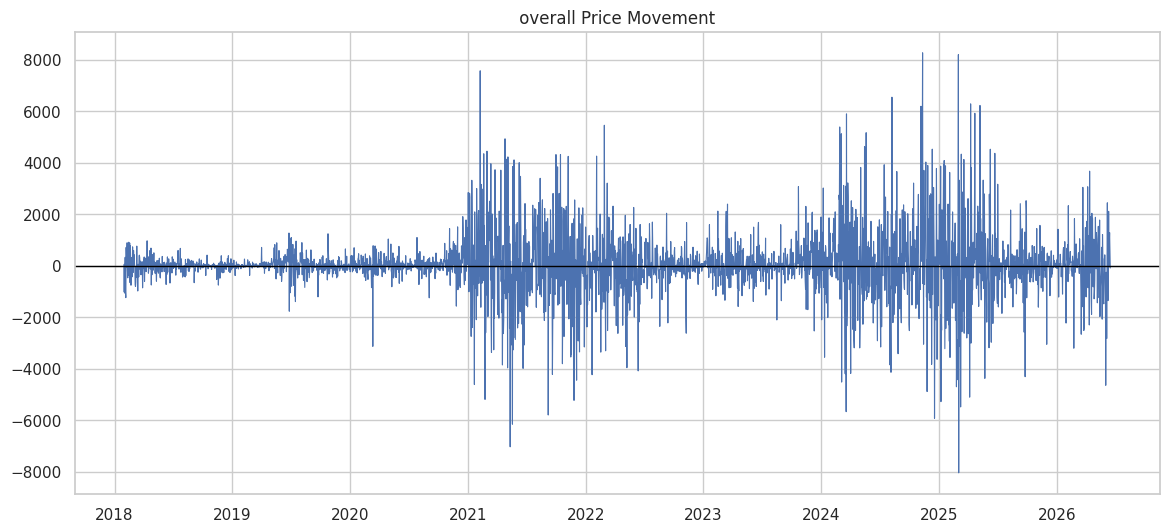

In [ ]:

# Overall price movment
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_filtered["Open time"], df_filtered["price_change"], linewidth=0.8)

plt.title(" overall Price Movement ")

plt.axhline(0, color="black", linewidth=1)

plt.show()

**How volatile the market within each intervall?**

This chart measures market volatility by calculating the difference between the High and Low prices in each interval.
Higher values indicate stronger price fluctuations and increased market risk, while lower values suggest more stable market conditions.


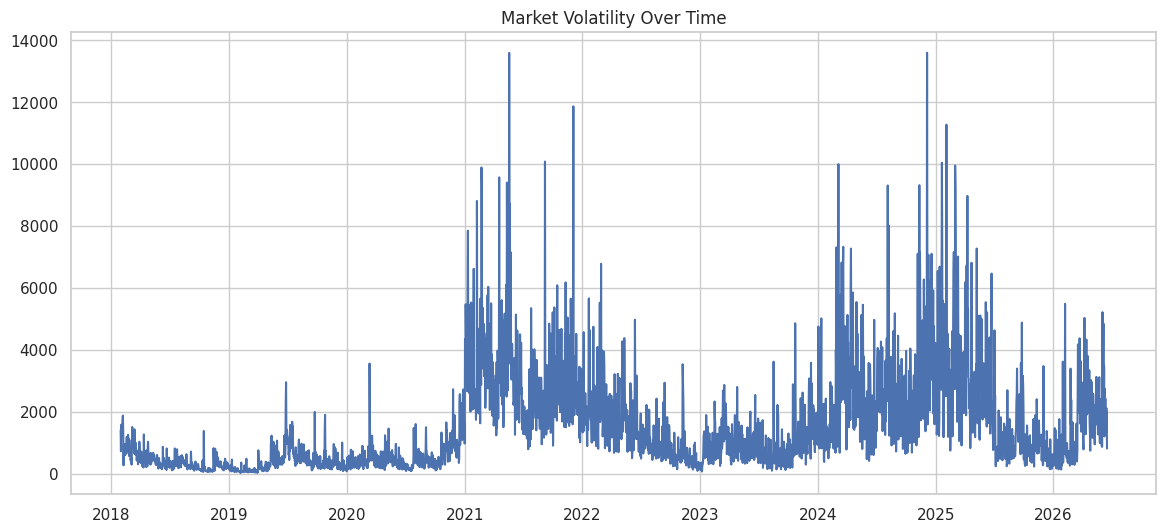

In [ ]:

# Market Volatility Over Time

plt.figure(figsize=(14,6))

plt.plot(df_filtered["Open time"], df_filtered["volatility"])

plt.title("Market Volatility Over Time")


plt.show()

**How much capital is flowing through the market?**

This chart shows the total capital flowing through the Bitcoin market over time .
Higher values indicate increased market liquidity and participation, while lower values suggest reduced trading activity.

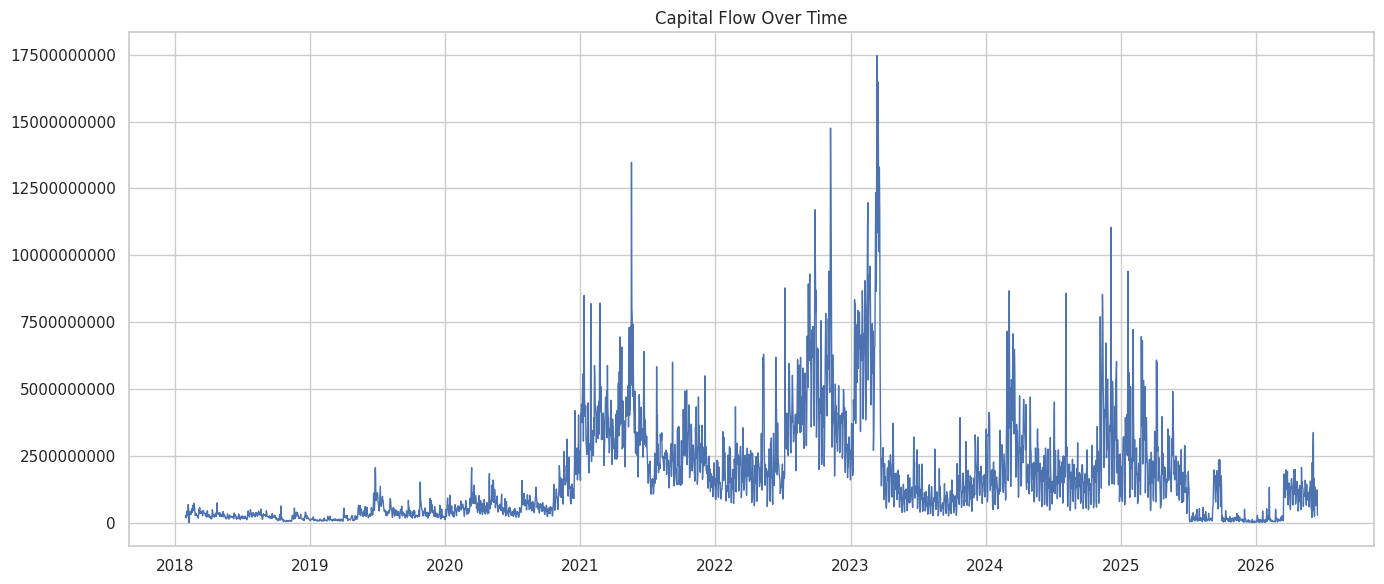

In [ ]:

# Capital Flow
plt.figure(figsize=(14,6))

plt.plot(
    df_filtered["Open time"],
    df_filtered["capital_flow"],
    linewidth=1
)

plt.title("Capital Flow Over Time")
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

**How many volume spike events occurred each year?**

This chart shows the number of volume spike events detected each year.
A volume spike occurs when trading volume becomes significantly higher than its recent average while the price also moves noticeably.
These events often indicate increased market participation and may precede strong price movements.

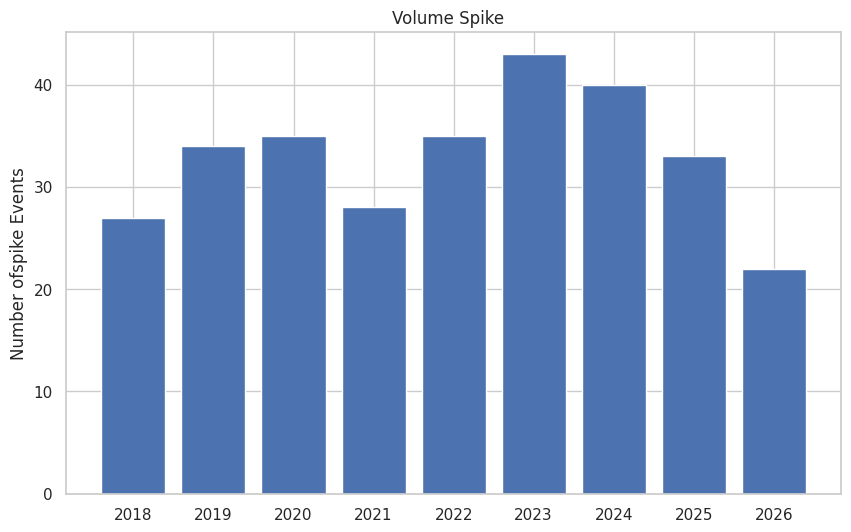

In [ ]:

# Volume Spike

volume_spike_by_year = (
    df_filtered.groupby("year")["volume_spike"]
      .sum()
)

plt.figure(figsize=(10,6))

plt.bar(
    volume_spike_by_year.index.astype(str),
    volume_spike_by_year.values
)

plt.title("Volume Spike  ")

plt.ylabel("Number ofspike Events")

plt.show()

# Buyer VS Sellyer Pressure

In [ ]:
#KPI CARDS

print(f"""
 total Buy pressure      : {df_filtered["buy_volume"].sum():,.2f}
 total sell pressure     : {df_filtered["sell_volume"].sum():,.2f}
 total Overheating signals : {df_filtered["overheating"].sum():,.2f}
""")


 total Buy pressure      : 93,710,939.77
 total sell pressure     : 94,916,724.25
 total Overheating signals : 1.00



**Who dominated the market buyer or seller?**

This chart compares the total Buy Ratio and Sell Ratio during the selected period, providing a snapshot of whether buyers or sellers dominated market activity.

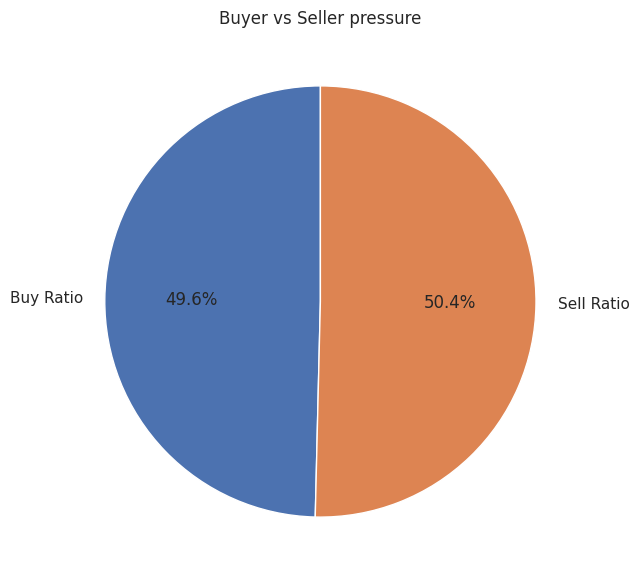

In [ ]:
# Buyer vs Seller pressure
buy_ratio = df_filtered["buy_ratio"].sum()
sell_ratio = df_filtered["sell_ratio"].sum()

plt.figure(figsize=(7,7))

plt.pie(
    [buy_ratio, sell_ratio],
    labels=["Buy Ratio", "Sell Ratio"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Buyer vs Seller pressure")

plt.show()

**how did the dominance differ across periods?**

This chart measures the net order flow by comparing buying and selling activity . Positive values indicate buyer dominance, while negative values highlight seller dominance


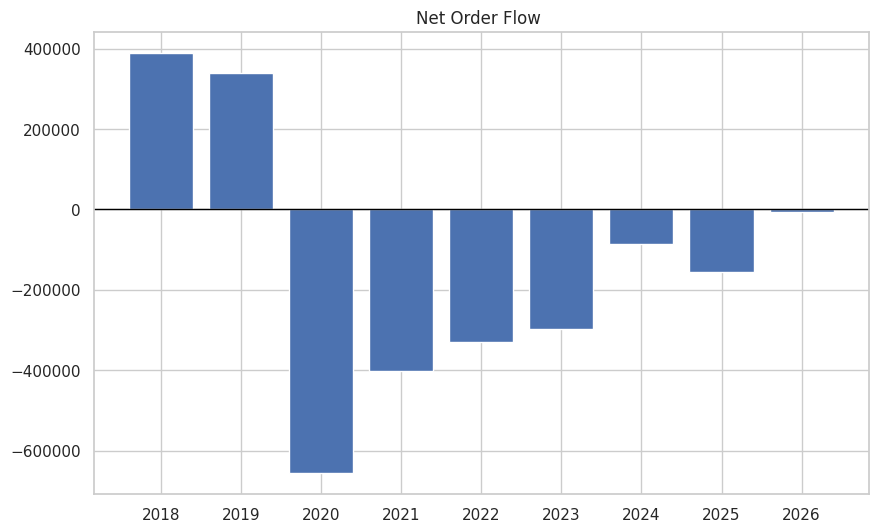

In [ ]:
# Net Order Flow

order_flow_by_year = (
    df_filtered.groupby("year")["order_flow"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.bar(
    order_flow_by_year.index.astype(str),
    order_flow_by_year.values
)

plt.axhline(y=0, color="black", linewidth=1)
plt.ticklabel_format(style="plain", axis="y")
plt.title("Net Order Flow ")

plt.show()

**When did excessive buying activity peak across years?**

This chart tracks the total number of events detected each year.
It helps identify the specific years where excessive buying activity was most frequent.


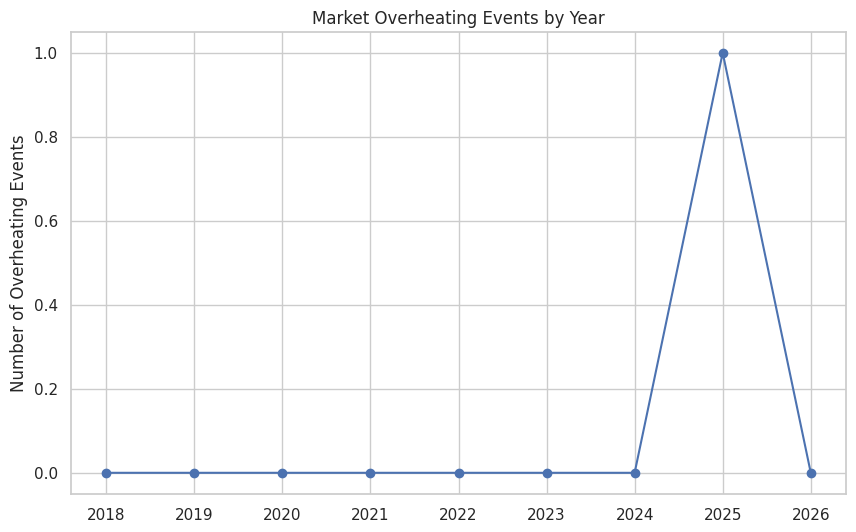

In [ ]:
# Market Overheating Events
overheating_by_year = (
    df_filtered.groupby("year")["overheating"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.plot(
    overheating_by_year.index.astype(str),
    overheating_by_year.values,
    marker="o"
)

plt.title("Market Overheating Events by Year")

plt.ylabel("Number of Overheating Events")

plt.show()

# LIQUIDITY , SUPPORT & RESISTENCE

In [ ]:
# KPI CARDs

print(f"""
averege price rejection   : {df_filtered["resistance"].mean():,.2f}
averege support strength   : {df_filtered["support"].mean():,.2f}
 consalidation range :       : {df_filtered["compression"].mean():,.2f}
""")


averege price rejection   : 693.83
averege support strength   : 802.96
 consalidation range :       : 0.13



**How did  price rejection change across years?**

 this chart compares the average price resistance across years. Higher values indicate that prices were rejected more strongly from session highs before closing.

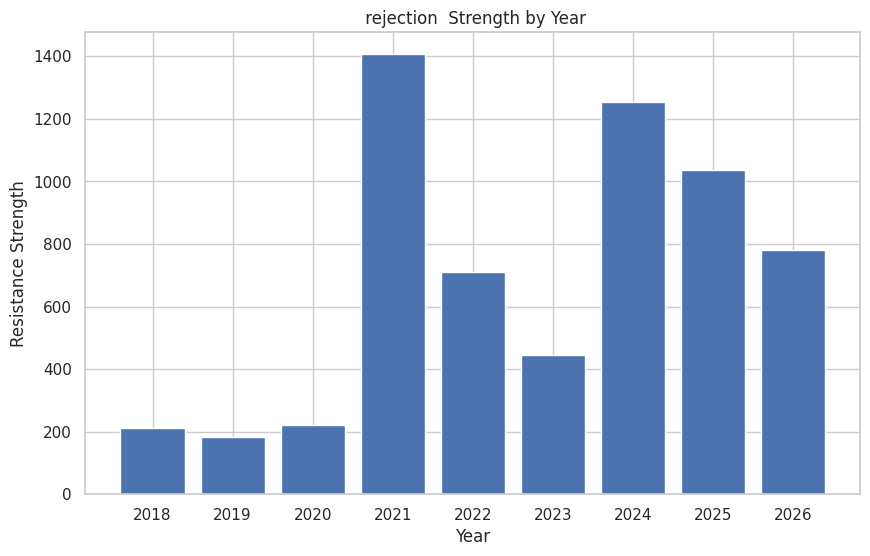

In [ ]:
# Resistance Strength

resistance_by_year = (
    df_filtered.groupby("year")["resistance"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.bar(
    resistance_by_year.index.astype(str),
    resistance_by_year.values
)

plt.title(" rejection  Strength by Year")
plt.xlabel("Year")
plt.ylabel("Resistance Strength")

plt.show()

**How did support strength change across years?**

Compares the average support strength across years. Higher values indicate that buyers pushed prices farther away from session lows before the close.

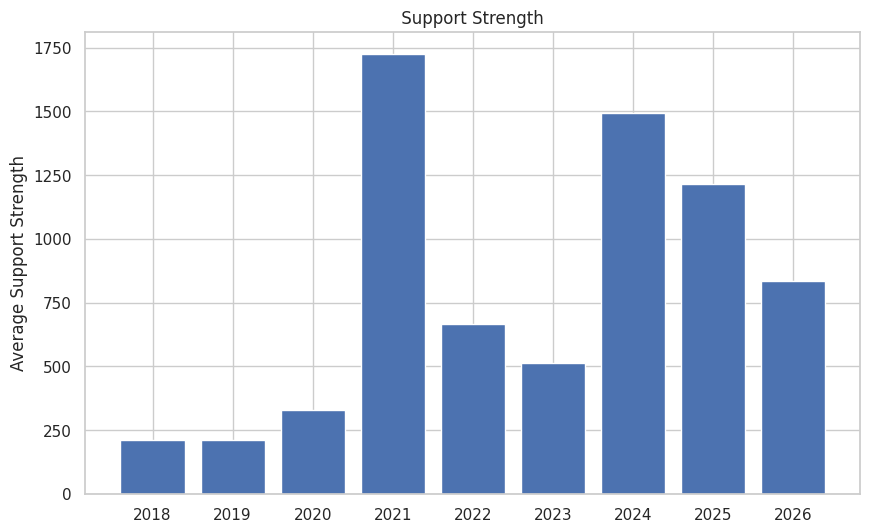

In [ ]:
#Support Strength
support_by_year = (
    df_filtered.groupby("year")["support"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.bar(
    support_by_year.index.astype(str),
    support_by_year.values
)

plt.title(" Support Strength ")

plt.ylabel("Average Support Strength")

plt.show()

**Is the market consolidating?**

This chart shows the annual percentage of time the market was in a compression state.
Higher values indicate longer periods of market consolidation and sideways movement.


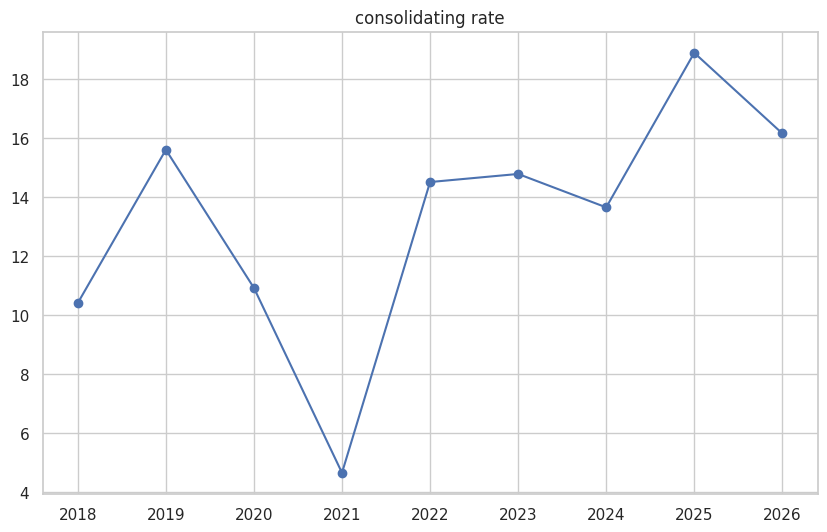

In [ ]:
# Market Consolidation Rate
compression_by_year = (
    df_filtered.groupby("year")["compression"]
    .mean()*100
)

plt.figure(figsize=(10,6))

plt.plot(
    compression_by_year.index.astype(str),
    compression_by_year.values,
    marker="o"
)

plt.title("consolidating rate")


plt.show()

**Where is the market most liquid?**

This chart shows the total trading volume across different price ranges to identify where market liquidity was highest. Higher trading volume indicates greater market liquidity at that price level.

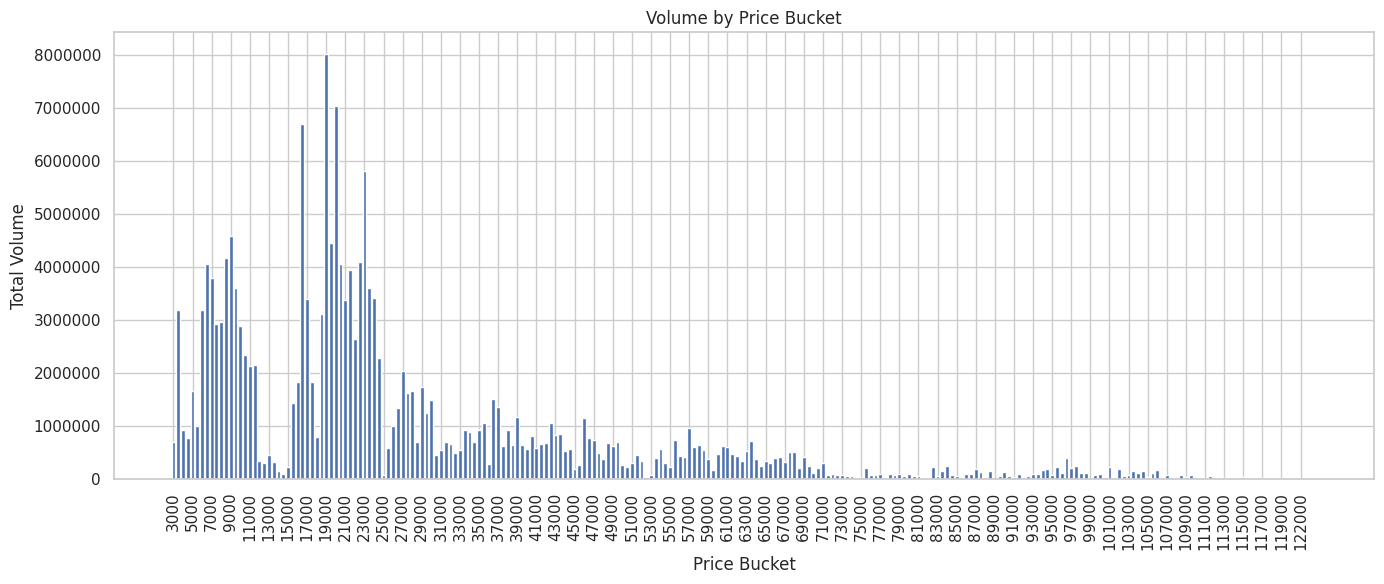

In [ ]:

# Create Price Bucket (every $500)
df_filtered["PriceBucket"] = (df_filtered["Close"] // 500) * 500

# Sum Volume by Price Bucket
price_bucket = (
    df_filtered.groupby("PriceBucket")["Volume"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.bar(
    price_bucket["PriceBucket"].astype(str),
    price_bucket["Volume"]
)

# Show every 10th price bucket only
step = 4

plt.xticks(
    range(0, len(price_bucket), step),
    price_bucket["PriceBucket"].astype(int)[::step],
    rotation=90
)

plt.title("Volume by Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Total Volume")
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

# trend & breakout tracking

In [ ]:
# KPI CARDs

print(f"""
averege Trend Stength   : {df_filtered["trend_strength"].mean():,.2f}
Maximam trend presistence   : {df_filtered["trend_length"].mean():,.2f}
 average compression    : {df_filtered["compression"].mean():,.2f}
""")


averege Trend Stength   : -34.35
Maximam trend presistence   : 1.86
 average compression    : 0.13



**Do increases in trading volume align with increases in trend strength?**

The chart compares overall trading volume with trend strength  to see whether both metrics move together or diverge.

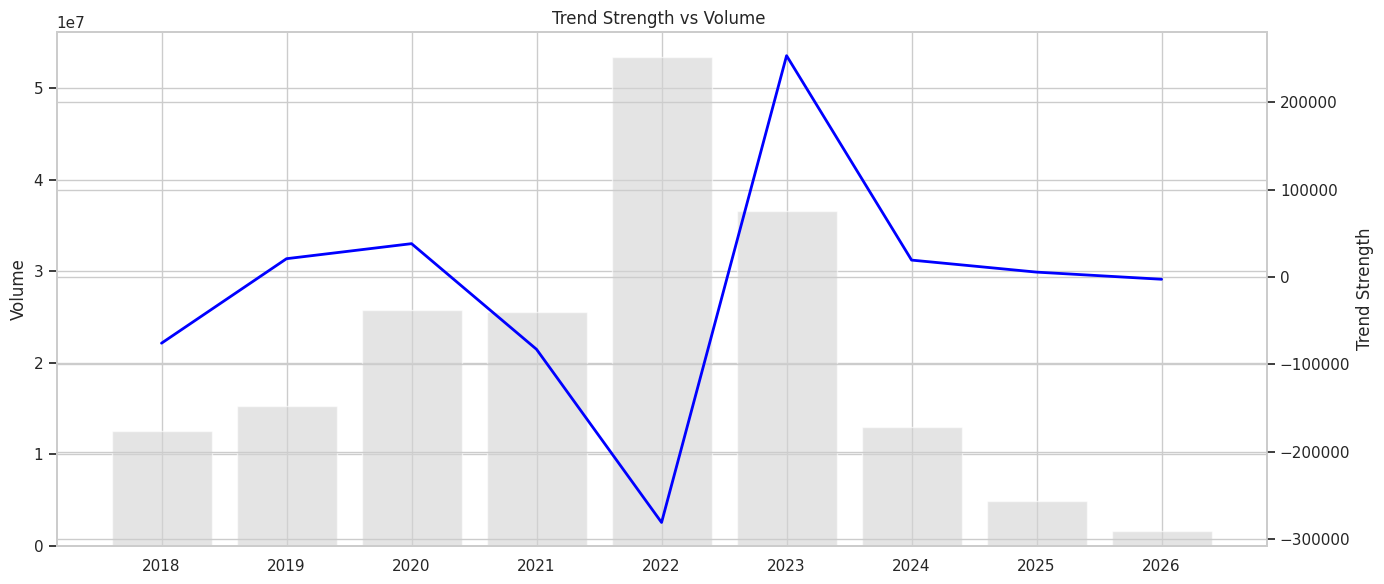

In [ ]:


#Trend Strength vs Volume

df_agg = df_filtered.groupby("year").agg({
    "Volume": "sum",
    "trend_strength": "sum"
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14,6))

# Volume (Bar - left axis)
ax1.bar(
    df_agg["year"].astype(str),
    df_agg["Volume"],
    color="lightgray",
    alpha=0.6
)
ax1.set_ylabel("Volume")

# Trend Strength (Line - right axis)
ax2 = ax1.twinx()

ax2.plot(
    df_agg["year"].astype(str),
    df_agg["trend_strength"],
    color="blue",
    linewidth=2
)
ax2.set_ylabel("Trend Strength")

plt.title("Trend Strength vs Volume ")
plt.tight_layout()
plt.show()

**What was the maximum duration a market trend sustained each year?**

This chart measures the maximum trend persistence by showing the longest continuous price move recorded each year.

Higher values indicate years with highly sustained trends where the market moved in the same direction for long, uninterrupted periods.

Lower values suggest frequent market reversals and choppy sideways trading.


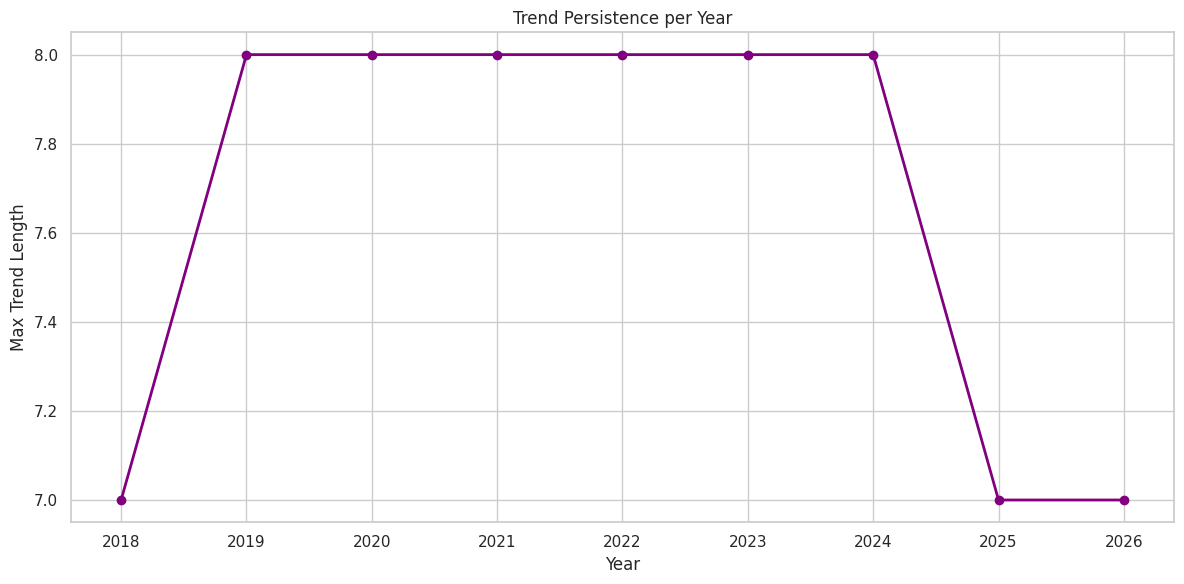

In [ ]:
#Trend Persistence

df_agg = df_filtered.groupby("year")["trend_length"].max().reset_index()

plt.figure(figsize=(12,6))

plt.plot(
    df_agg["year"],
    df_agg["trend_length"],
    marker="o",
    color="purple",
    linewidth=2
)

plt.title("Trend Persistence per Year")
plt.xlabel("Year")
plt.ylabel("Max Trend Length")

plt.tight_layout()
plt.show()

**Are breakout trends occurring?**

This chart tracks the price levels where major market breakout trends occurred over time.

It highlights the closing price of the latest breakout events detected each year, whether moving upward or downward.

This helps identify structural shifts in the Bitcoin price and new trend formations.


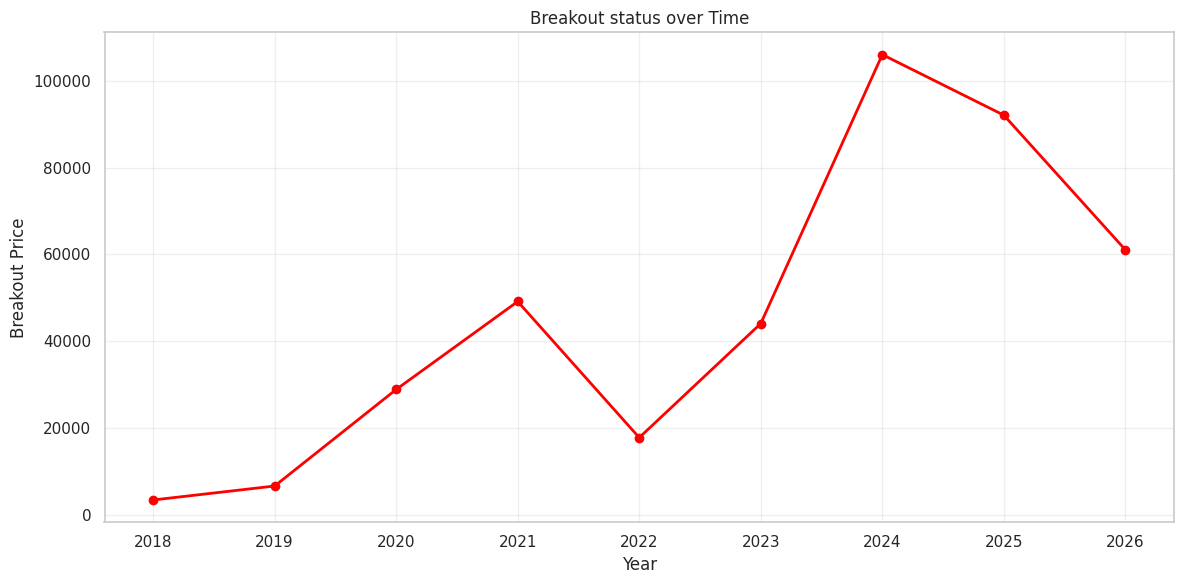

In [ ]:
#Breakout status over Time
breakout_status = (
    df_filtered[
        (df_filtered["breakout_up"] == 1) |
        (df_filtered["breakout_down"] == 1)
    ]
    .sort_values("date_key")
    .groupby("year")
    .tail(1)
)

plt.figure(figsize=(12,6))

plt.plot(
    breakout_status["year"],
    breakout_status["Close"],
    marker="o",
    linewidth=2,
    color="red"
)

plt.title("Breakout status over Time")
plt.xlabel("Year")
plt.ylabel("Breakout Price")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#trade activity and whale watch

In [ ]:
# KPI CARDs

print(f"""
Total trades  : {df_filtered["trade_activity"].sum():,.2f}
 total Whale flages  : {df_filtered["whale_activity"].sum():,.2f}
  volatility clusters  : {df_filtered["high_volatility_length"].max():,.2f}
""")


Total trades  : 5,454,909,720.00
 total Whale flages  : 20.00
  volatility clusters  : 19.00



**How active are traders in the market?**

this chart Shows the total trading activity in each period, helping identify whether market participation is increasing or decreasing over time.
Higher values indicate greater market participation and more intense trading activity, suggesting stronger engagement from market participants.

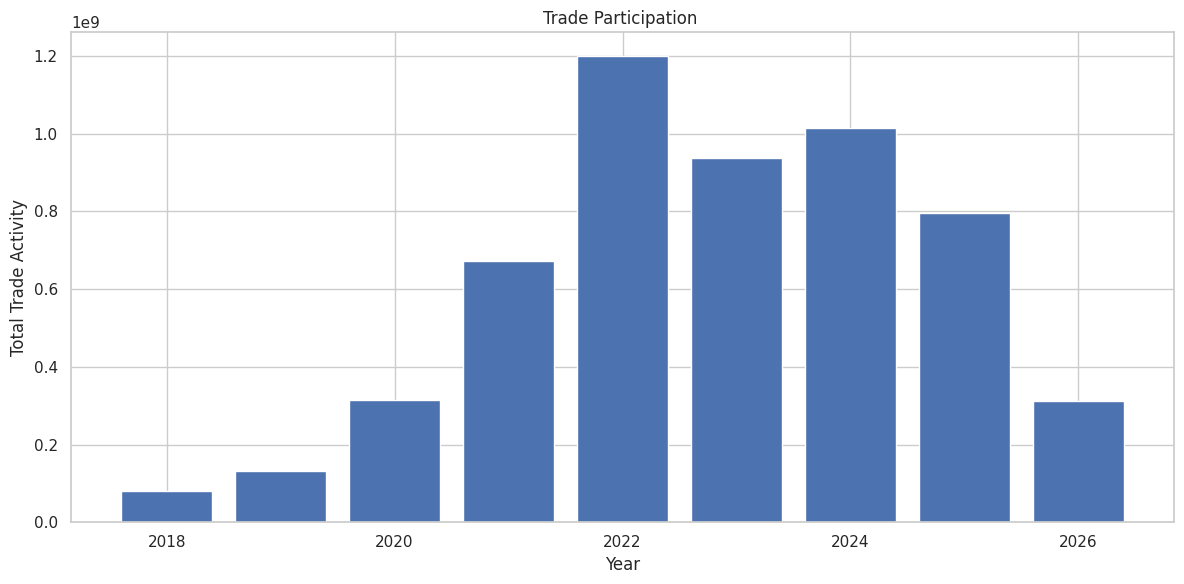

In [ ]:
#Trade Participation
trade_participation = (
    df_filtered.groupby("year")["trade_activity"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.bar(
    trade_participation["year"],
    trade_participation["trade_activity"]
)

plt.title("Trade Participation ")
plt.xlabel("Year")
plt.ylabel("Total Trade Activity")

plt.tight_layout()
plt.show()

**Is market volume driven by many small trades or a few large trades?**

Shows the number of trades relative to trading volume, helping identify whether market activity is driven by many small trades or fewer large trades.

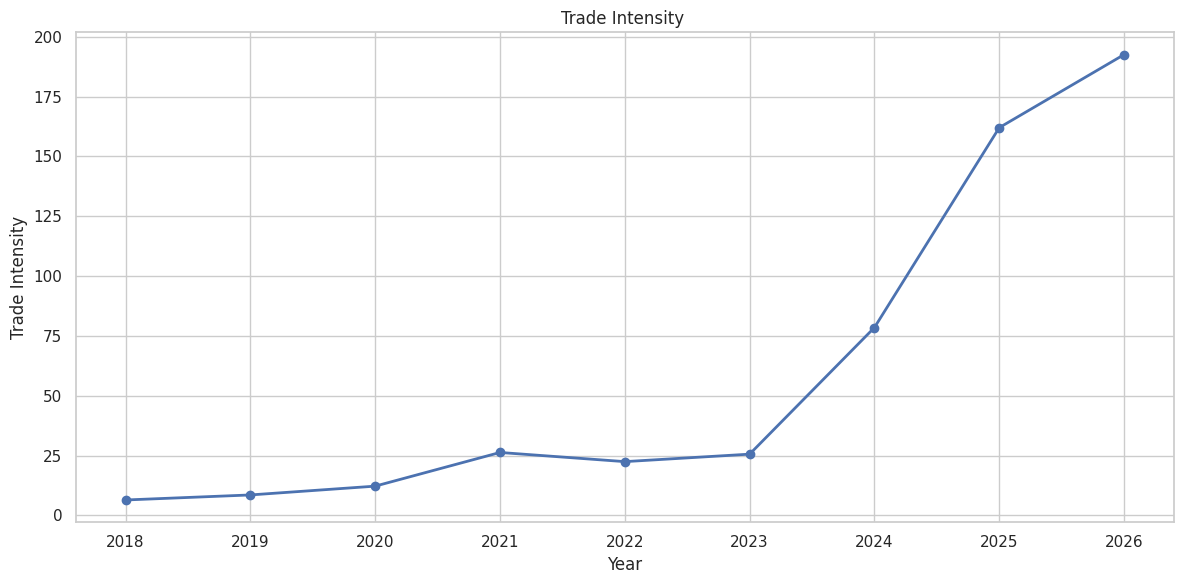

In [ ]:
#trade_intensity

trade_intensity = (
    df_filtered.groupby("year")
    .agg({
        "trade_activity": "sum",
        "Volume": "sum"
    })
    .reset_index()
)

trade_intensity["trade_intensity"] = (
    trade_intensity["trade_activity"] /
    trade_intensity["Volume"]
)

plt.figure(figsize=(12,6))

plt.plot(
    trade_intensity["year"],
    trade_intensity["trade_intensity"],
    marker="o",
    linewidth=2
)

plt.title("Trade Intensity ")
plt.xlabel("Year")
plt.ylabel("Trade Intensity")

plt.tight_layout()
plt.show()

**Which periods experienced the highest whale activity?**

 this chart shows the total whale activity across each period to identify when large market participants were most active.

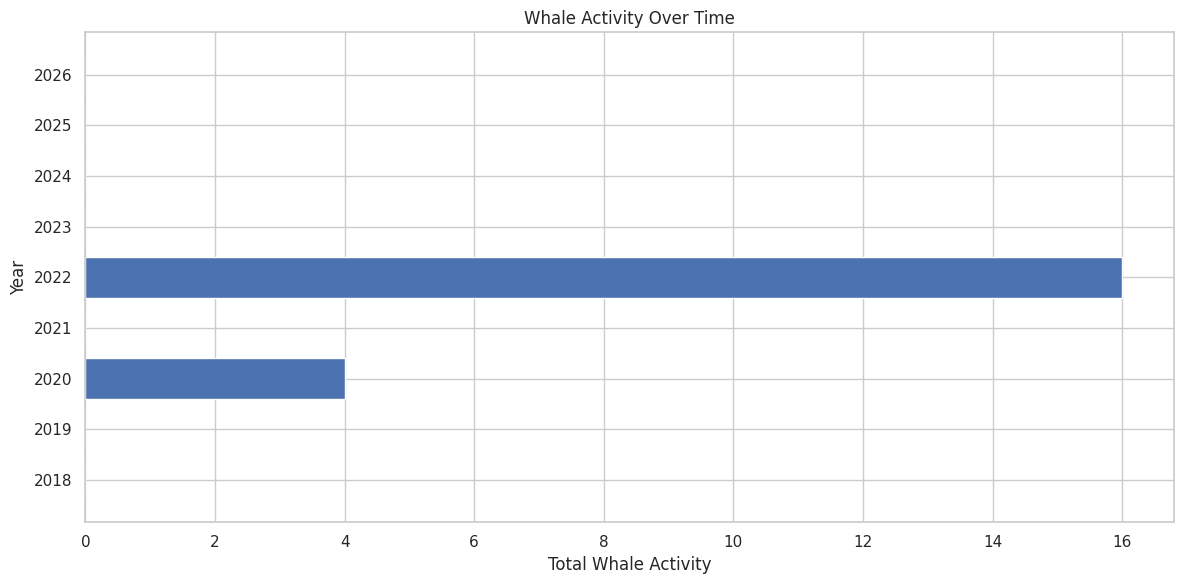

In [ ]:
#Whale watch
whale_activity= (
     df_filtered.groupby("year")["whale_activity"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.barh(
    whale_activity["year"].astype(str),
    whale_activity["whale_activity"]
)

plt.title("Whale Activity Over Time")
plt.xlabel("Total Whale Activity")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

**Which periods experienced the longest sustained high-volatility phases?**





This chart compares the longest continuous high-volatility periods , helping identify when market instability persisted for the longest duration.

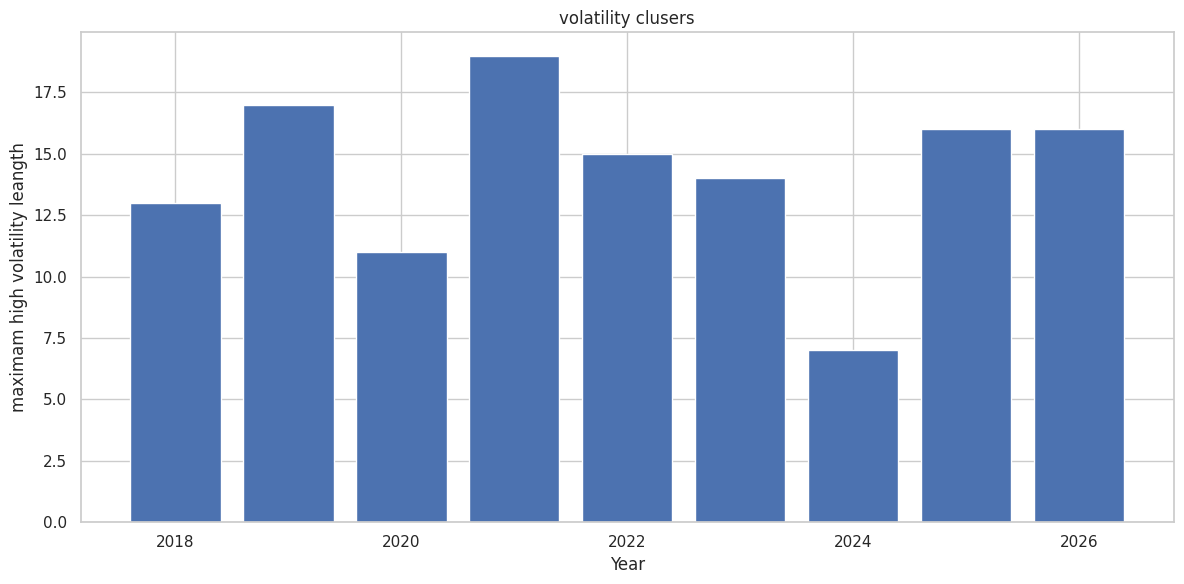

In [ ]:
# volatility clusers

max_high_volatility_length = (
    df_filtered.groupby("year")["high_volatility_length"]
    .max()
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.bar(

max_high_volatility_length["year"],

max_high_volatility_length["high_volatility_length"]
)

plt.title("volatility clusers")
plt.xlabel("Year")
plt.ylabel("maximam high volatility leangth")

plt.tight_layout()
plt.show()

# more  charts & questions

**How frequently do market trends persist across different lengths?**

This chart shows the distribution of market trend lengths by counting how many times each trend duration occurred.

Higher bars on the left indicate that short-lived trends and frequent direction changes are more common.

bars stretching to the right suggest rare but highly sustained market trends.
.

In [ ]:

#Trend Persistence Distribution
trend_counts = df_filtered["trend_length"].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(trend_counts.index, trend_counts.values)

plt.title("Trend Persistence Distribution")
plt.xlabel("Consecutive Trend Length")
plt.ylabel("Number of Occurrences")

plt.show()

**Which breakout trends dominated the market each year?**

This chart compares the number of bullish and bearish breakout events each year. A breakout is recorded when the price moves beyond its recent trading range with above-average trading volume, indicating a potentially significant market move.

In [ ]:

# Market Breakout Events by Year

breakout_by_year = (
    df_filtered
    .groupby("year")[["breakout_up", "breakout_down"]]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12,6))

x = range(len(breakout_by_year))

width = 0.35

plt.bar(
    [i - width/2 for i in x],
    breakout_by_year["breakout_up"],
    width=width,
    label="Breakout Up"
)

plt.bar(
    [i + width/2 for i in x],
    breakout_by_year["breakout_down"],
    width=width,
    label="Breakout Down"
)

plt.xticks(x, breakout_by_year.index.astype(str))

plt.title("Market Breakout Events by Year")
plt.xlabel("Year")
plt.ylabel("Number of Breakout Events")

plt.legend()

plt.show()